# Natural Language to SQL

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/nl-to-sql/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/nl-to-sql/demo.ipynb)

> Non-analysts can't query the warehouse. NL→SQL lets them ask in English — behind guardrails that keep it read-only and in-schema.

The scary part of "just let an LLM write SQL" isn't the SQL - it's what happens when it writes
`DROP TABLE` or reaches into a table it shouldn't. This build puts a **guardrail layer** between
the question and the database, so *neither* a rule-based translator *nor* an LLM can produce
anything but a safe, scoped, read-only query.

**What this notebook covers**
1. A whitelisted schema (the only tables/columns allowed)
2. A rule-based NL→SQL translator (no API key)
3. The guardrail that vets every query - and blocks attacks
4. Executing safe SQL against real data
5. Why the guardrail matters, visualized


## Step 1 - The schema is the boundary

Everything downstream is scoped to this one table and its columns. Anything referencing something
*not* here gets rejected - that's the core safety property.

In [1]:
from nl2sql import (translate, guard_sql, run_sql, heuristic_translate,
                    SCHEMA, sample_dataframe, SAMPLE_QUESTIONS)

print("Table:", SCHEMA.table)
for col, typ in SCHEMA.columns.items():
    print(f"  {col:<10} {typ}")


Table: orders
  order_id   num
  amount     num
  region     text
  plan       text
  status     text


## Step 2 - Rule-based translation (no LLM)

For common analytic shapes - count, sum, average, top-N, group-by, simple filters - we don't even
need a model. Deterministic, free, and easy to audit.

In [2]:
for q in SAMPLE_QUESTIONS:
    print("Q:", q)
    print("   ", heuristic_translate(q, SCHEMA).replace(chr(10), " "))


Q: How many orders are there?
    SELECT COUNT(*) AS n FROM orders
Q: What is the total amount by region?
    SELECT region, SUM(amount) AS sum_amount FROM orders GROUP BY region
Q: Show the average amount for plan pro
    SELECT AVG(amount) AS avg_amount FROM orders WHERE plan = 'pro'
Q: Top 3 regions by total amount
    SELECT region, SUM(amount) AS sum_amount FROM orders GROUP BY region ORDER BY sum_amount DESC LIMIT 3


## Step 3 - The guardrail vets everything

Rule-based or LLM, the SQL flows through `guard_sql`. It rejects non-SELECT, write/DDL keywords,
multiple statements, and any unknown table or column - then injects a `LIMIT` so nothing runs away.

In [3]:
attacks = [
    "DROP TABLE orders",
    "SELECT * FROM users",
    "SELECT amount FROM orders; DELETE FROM orders",
    "SELECT credit_card FROM orders",
    "UPDATE orders SET amount = 0",
]
for a in attacks:
    r = guard_sql(a, SCHEMA)
    print(f"BLOCKED={not r.ok}  {a[:42]:<44} {r.issues[0] if r.issues else ''}")


BLOCKED=True  DROP TABLE orders                            Only SELECT queries are allowed
BLOCKED=True  SELECT * FROM users                          Unknown table: users
BLOCKED=True  SELECT amount FROM orders; DELETE FROM ord   Contains a forbidden write/DDL keyword
BLOCKED=True  SELECT credit_card FROM orders               Unknown identifier: credit_card
BLOCKED=True  UPDATE orders SET amount = 0                 Only SELECT queries are allowed


## Step 4 - Ask in English, get an answer

The full path: English question → translate → guard → execute against the data (in-memory SQLite).
A non-analyst never sees the SQL unless they want to.

In [4]:
df = sample_dataframe()
for q in SAMPLE_QUESTIONS:
    g = translate(q, SCHEMA)
    print("Q:", q)
    if g.ok:
        print("   ->", run_sql(g.sql, df, SCHEMA.table).to_dict("records"))
    else:
        print("   BLOCKED:", g.issues)
    print()


Q: How many orders are there?
   -> [{'n': 8}]

Q: What is the total amount by region?
   -> [{'region': 'APAC', 'sum_amount': 80}, {'region': 'EU', 'sum_amount': 200}, {'region': 'US', 'sum_amount': 300}]

Q: Show the average amount for plan pro
   -> [{'avg_amount': 75.0}]

Q: Top 3 regions by total amount
   -> [{'region': 'US', 'sum_amount': 300}, {'region': 'EU', 'sum_amount': 200}, {'region': 'APAC', 'sum_amount': 80}]



## Step 5 - The guardrail's job, visualized

Of a realistic mix of inbound queries - some innocent, some dangerous - how many the guardrail lets
through vs blocks. Every red one is an incident that didn't happen.

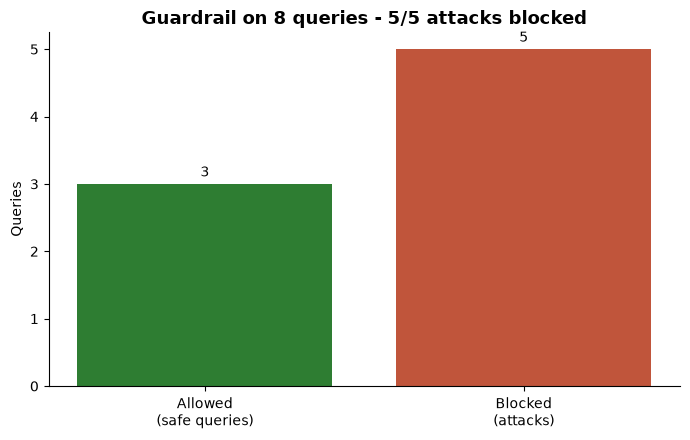

In [5]:
import matplotlib.pyplot as plt

queries = [
    ("SELECT COUNT(*) FROM orders", "safe"),
    ("SELECT region, SUM(amount) FROM orders GROUP BY region", "safe"),
    ("SELECT AVG(amount) FROM orders WHERE plan='pro'", "safe"),
    ("DROP TABLE orders", "attack"),
    ("SELECT * FROM users", "attack"),
    ("DELETE FROM orders", "attack"),
    ("SELECT amount FROM orders; DROP TABLE orders", "attack"),
    ("SELECT ssn FROM orders", "attack"),
]
allowed = sum(1 for sql, _ in queries if guard_sql(sql, SCHEMA).ok)
blocked = len(queries) - allowed
attacks_blocked = sum(1 for sql, kind in queries if kind == "attack" and not guard_sql(sql, SCHEMA).ok)
attacks_total = sum(1 for _, kind in queries if kind == "attack")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["Allowed\n(safe queries)", "Blocked\n(attacks)"], [allowed, blocked],
              color=["#2e7d32", "#c0553b"])
ax.set_title(f"Guardrail on {len(queries)} queries - {attacks_blocked}/{attacks_total} attacks blocked",
             fontsize=13, weight="bold")
ax.set_ylabel("Queries")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("guardrail_outcomes.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Layer | Job |
|-------|-----|
| Schema | defines the only legal tables/columns |
| Translator | English → candidate SQL (rules or Claude) |
| **Guardrail** | rejects unsafe/out-of-scope SQL, injects LIMIT |
| Executor | runs the vetted query |

The translator is swappable; the **guardrail is not**. Whether SQL comes from a regex or a
frontier model, it passes the same gate - so "let non-analysts query" never becomes "let anyone
drop a table."

**Extend it:** point the executor at your warehouse, add row-level security to the schema, and log
every blocked query for review.

In [6]:
# --- Try your own question ---
# g = translate("total amount for region US", SCHEMA)
# print(g.sql, "| ok:", g.ok)
# if g.ok:
#     print(run_sql(g.sql, sample_dataframe(), SCHEMA.table))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 102,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`